In [1]:
from optunaz.three_step_opt_build_merge import (
    optimize,
    buildconfig_best,
    build_best)

from optunaz.config import ModelMode, OptimizationDirection
from optunaz.config.optconfig import (
    OptimizationConfig,
    RandomForestClassifier,
    SVC,
    LogisticRegression,
    KNeighborsClassifier,
)
from optunaz.datareader import Dataset
from optunaz.descriptors import (ECFP,
                                 ECFP_counts,
                                 MACCS_keys,
                                 UnscaledPhyschemDescriptors,
                                 CompositeDescriptor,
                                 PhyschemDescriptors)
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import auc as AUC
from optunaz.utils.preprocessing.splitter import Stratified
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, average_precision_score

sns.set_theme(style='white', palette='bright')

In [3]:
config = OptimizationConfig(        # config setup for hyperparameter optimization
    
    data = Dataset(
        input_column = 'Structure',
        response_column = 'Class',
        training_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_train_NM-RS42.csv',
        test_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_NM-RS42.csv',
    ),
    descriptors=[
        ECFP.new(),
        ECFP_counts.new(),
        MACCS_keys.new(),
        PhyschemDescriptors.new(),
        UnscaledPhyschemDescriptors.new(),
        CompositeDescriptor.new(
            descriptors=[
                ECFP_counts.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                MACCS_keys.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                ECFP.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        )
    ],
    algorithms=[
        RandomForestClassifier.new(),
        SVC.new(),
        LogisticRegression.new(),
        KNeighborsClassifier.new(),
    ],
    settings=OptimizationConfig.Settings(
        mode=ModelMode.CLASSIFICATION,
        cross_validation=10,
        cv_split_strategy=Stratified(),
        n_trials=200,
        n_startup_trials=50,
        direction=OptimizationDirection.MAXIMIZATION,
        random_seed=42,
        n_jobs=-1
    ),
)

# study = optimize(config, study_name='study')                                                                         # run the optimization                                   

# build_best(buildconfig_best(study), "./tm60.pkl")                                  # build a model from the best trial and configuration

with open(r"M:\ML_scripts\github_files\tm60.pkl", "rb") as f:                                                              # load the model
    model = pickle.load(f)


test_data = pd.read_csv(config.data.test_dataset_file)              # load the test data
test_smiles = test_data[config.data.input_column]                   # test structures
y_true = test_data[config.data.response_column]                     # test ground truth labels

y_pred = model.predict_from_smiles(test_smiles)                     # model predictions on test set structures

train_data = pd.read_csv(config.data.training_dataset_file)         # predict on train structures

train_preds = model.predict_from_smiles(train_data[config.data.input_column], explain=True)     # uses SHAP explainer to explain the model

In [4]:
shap_df = pd.DataFrame(train_preds)

In [6]:
shap_df.head(15)

,shap_value,descriptor,bit,info
1673,0.061811,ECFP_counts,1673,C(C)(C)N
178,0.027172,ECFP_counts,178,c1(Oc(c)c)cccc(C)c1
1126,0.015978,ECFP_counts,1126,C(NC(C)C)(=O)C(CC)N(C)C
1850,0.012902,ECFP_counts,1850,O(C)C
677,0.012881,ECFP_counts,677,C(CN(C)C)CNC
1584,0.012565,ECFP_counts,1584,C(CN)NC
691,0.011323,ECFP_counts,691,C(N)(=O)C
2017,0.009280,ECFP_counts,2017,c(c)c
927,0.008253,ECFP_counts,927,C(NC)(=O)C(C)N
1482,0.005827,ECFP_counts,1482,c1c(CO)cccc1Oc


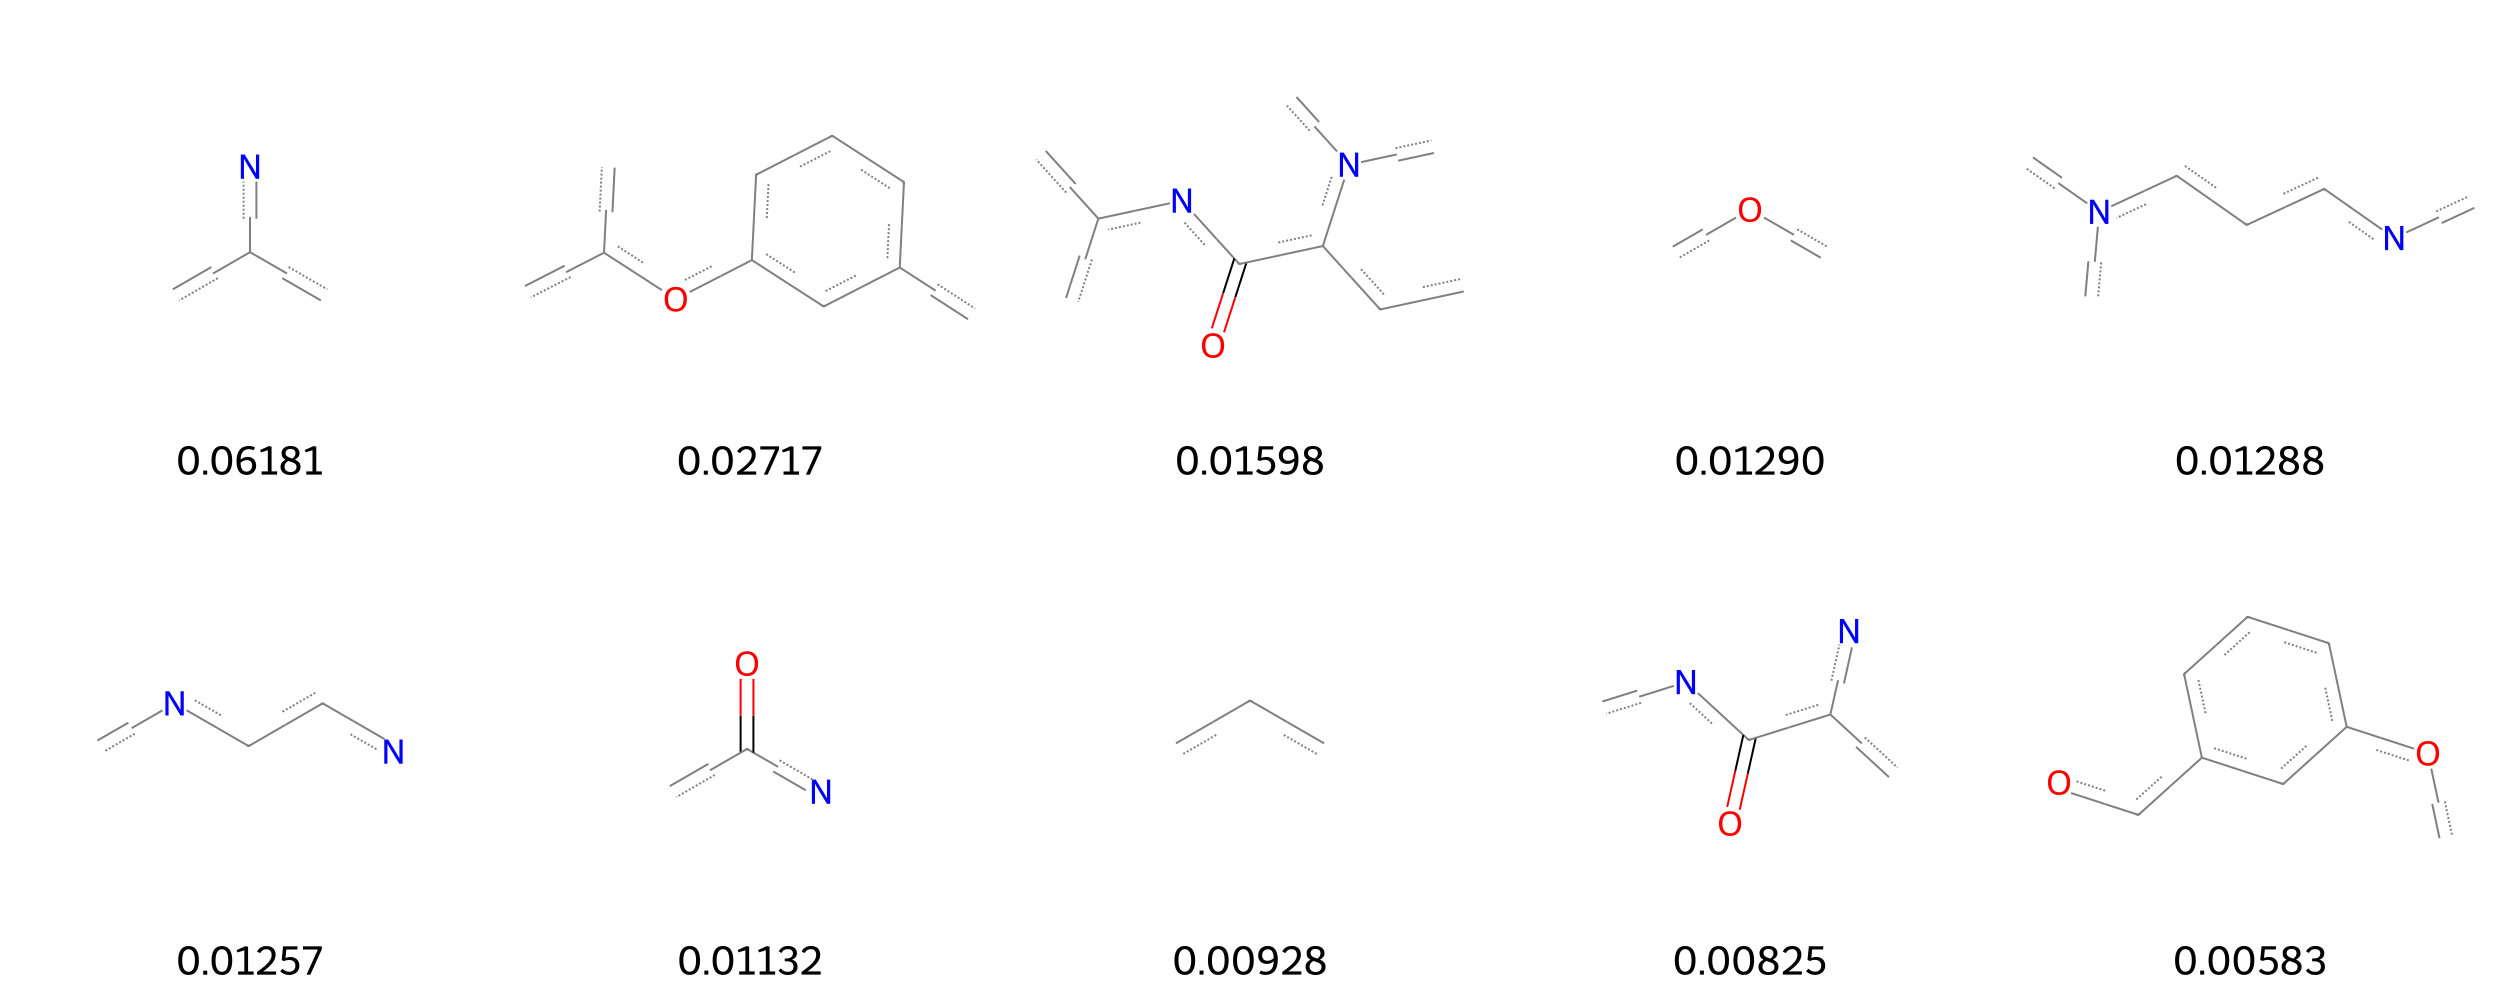

In [7]:
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmarts(smiles) for smiles in shap_df['info'][:10]]
shap_vals = shap_df['shap_value'][:10].tolist()
shap_vals_5dp=[]
for x in shap_vals:
    num = '{:.5f}'.format(x)
    shap_vals_5dp.append(num)
shap_val_str = list(map(str, shap_vals_5dp))

options = Draw.MolDrawOptions()
options.legendFontSize = 40

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(500,500), legends=(shap_val_str), useSVG=False, drawOptions=options)